# Zomato Restaurant EDA - Exploratory Data Analysis
###Data Analytics Project - Zomato Dataset
---


Zomato is one of India's largest food delivery and restaurant discovery platforms. In this project we will work through their global restaurant dataset - **9,551 restaurants** across multiple countries — and answer the kind of questions a food-tech business actually needs answered:

- Which cities and cuisines have the highest-rated restaurants?
- What is the relationship between cost, rating, and votes?
- Which price range delivers the best value?
- Does online delivery affect restaurant ratings?
- Where are the outliers and what do they tell us?

### What this notebook covers
1. Introduction to EDA
2. Understanding the Dataset
3. Data Quality Assessment
4. Univariate Analysis
5. Bivariate Analysis
6. Multivariate Analysis
7. Outlier & Missing Value Analysis
8. Feature Relationships & Pattern Discovery
9. Insights & Business Conclusions
10. Complete End-to-End EDA Summary

Let's get started.

---
## Phase 1 - Introduction to Exploratory Data Analysis

**What is EDA?**  
Exploratory Data Analysis (EDA) is the process of **visually and statistically investigating a dataset** before building models or dashboards. It was popularized by statistician John Tukey in the 1970s.

**Why EDA before Machine Learning?**  
- You cannot build a good model on bad or misunderstood data  
- EDA reveals hidden patterns, outliers, and relationships  
- It tells you **which features matter** and which don't  
- It prevents costly mistakes downstream

**The EDA Workflow:**
```
Load Data → Understand Structure → Assess Quality → Univariate → Bivariate → Multivariate → Insights
```


---
## Phase 2 — Setting Up & Loading the Dataset

In [35]:
#Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


**Business Scenario:** The Zomato data team has shared a global restaurant dataset for analysis. Before anything else, we load it and take a first look.

In [36]:
#Loading the DataSet

df = pd.read_csv('zomato.csv',encoding="latin1")
df.head(1)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314


Understanding the Data

In [37]:
df.shape

(9551, 21)

In [38]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

In [39]:
df.dtypes

,0
Restaurant ID,int64
Restaurant Name,object
Country Code,int64
City,object
Address,object
Locality,object
Locality Verbose,object
Longitude,float64
Latitude,float64
Cuisines,object


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [41]:
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [42]:
numeric_columns = df.select_dtypes(include="number").columns

print(numeric_columns)

Index(['Restaurant ID', 'Country Code', 'Longitude', 'Latitude',
       'Average Cost for two', 'Price range', 'Aggregate rating', 'Votes'],
      dtype='object')


In [43]:
categorical_columns = df.select_dtypes(include="object").columns
print(categorical_columns)

Index(['Restaurant Name', 'City', 'Address', 'Locality', 'Locality Verbose',
       'Cuisines', 'Currency', 'Has Table booking', 'Has Online delivery',
       'Is delivering now', 'Switch to order menu', 'Rating color',
       'Rating text'],
      dtype='object')


**Phase 3 - Data Quality Assessment**

In [44]:
#To check the missing values in the DataSet
missing_values = df.isnull().sum()
missing_values

,0
Restaurant ID,0
Restaurant Name,0
Country Code,0
City,0
Address,0
Locality,0
Locality Verbose,0
Longitude,0
Latitude,0
Cuisines,9


<Axes: >

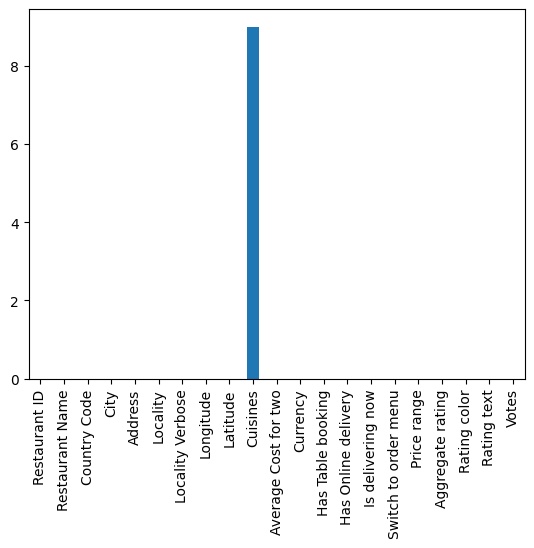

In [45]:
missing_values.plot(kind = "bar")

In [46]:
#To check the Duplicate values are present or not in the dataset
duplicate_values = df.duplicated().sum()
duplicate_values

np.int64(0)

In [47]:
#To fill the Null values in the "Cuisines" column
df["Cuisines"] = df["Cuisines"].fillna("Unknown")

In [48]:
#To check the Inconsistencies in the DataSet
for col in ["Has Table booking","Has Online delivery","Is delivering now","Switch to order menu"]:
  print(f"{col}:{df[col].unique()}")

Has Table booking:['Yes' 'No']
Has Online delivery:['No' 'Yes']
Is delivering now:['No' 'Yes']
Switch to order menu:['No']


In [49]:
#To check the Data Completness
completeness = (1 - df.isnull().mean()) * 100

print(completeness)

Restaurant ID           100.0
Restaurant Name         100.0
Country Code            100.0
City                    100.0
Address                 100.0
Locality                100.0
Locality Verbose        100.0
Longitude               100.0
Latitude                100.0
Cuisines                100.0
Average Cost for two    100.0
Currency                100.0
Has Table booking       100.0
Has Online delivery     100.0
Is delivering now       100.0
Switch to order menu    100.0
Price range             100.0
Aggregate rating        100.0
Rating color            100.0
Rating text             100.0
Votes                   100.0
dtype: float64


---
## Phase 4 — Univariate Analysis

**Business Scenario:** Study each variable individually to understand its distribution and behavior.  
**What we'll use:** Histograms, Box plots, KDE plots, Value counts, Bar charts.

In [50]:
# We perform Statistics only on Numerical Columns
stats = df[[
    "Aggregate rating",
    "Rating color",
    "Rating text",
    "Votes",
    "Average Cost for two",
    "Price range"
]].describe()

In [51]:
stats

,Aggregate rating,Votes,Average Cost for two,Price range
count,9551.000000,9551.000000,9551.000000,9551.000000
mean,2.666370,156.909748,1199.210763,1.804837
std,1.516378,430.169145,16121.183073,0.905609
min,0.000000,0.000000,0.000000,1.000000
25%,2.500000,5.000000,250.000000,1.000000
50%,3.200000,31.000000,400.000000,2.000000
75%,3.700000,131.000000,700.000000,2.000000
max,4.900000,10934.000000,800000.000000,4.000000


Text(0, 0.5, 'Number of Restaurants')

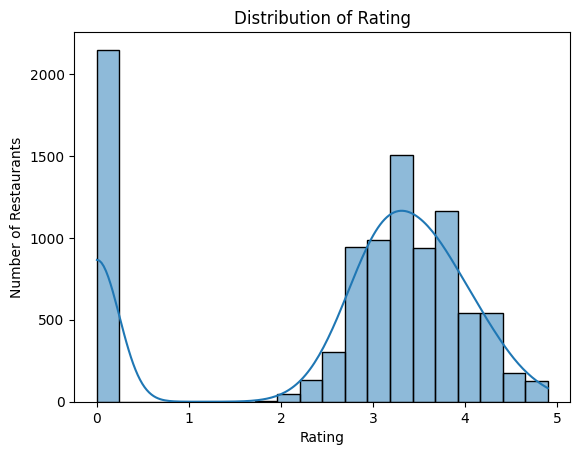

In [52]:
# Focuses on the Rating column (For Univariet Analysis)
sns.histplot(df["Aggregate rating"],bins = 20,kde = True)
plt.title("Distribution of Rating")
plt.xlabel("Rating")
plt.ylabel("Number of Restaurants")


In [53]:
# Huge difference in Mean and Median in the "Aggregate rating" column

df["Aggregate rating"].value_counts()

# Many 0 star rating might be important to check

,count
Aggregate rating,
0.0,2148
3.2,522
3.1,519
3.4,498
3.3,483
3.5,480
3.0,468
3.6,458
3.7,427


In [54]:
# To check the skewness of the Rating column
skewness = df["Aggregate rating"].skew()
skewness

np.float64(-0.9541304733200109)

In [55]:
# To check the types of the "Rating text" is available in the DataSet
rate_text = df["Rating text"].value_counts()
rate_text

,count
Rating text,
Average,3737
Not rated,2148
Good,2100
Very Good,1079
Excellent,301
Poor,186


<Axes: xlabel='Rating text'>

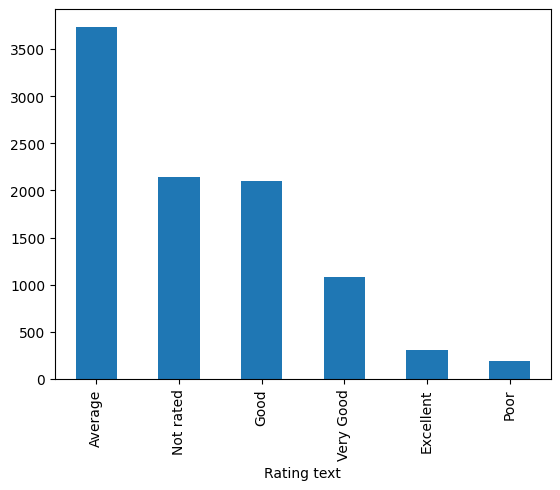

In [56]:
# To see the visual-representation of the Text-rating
rate_text.plot(kind = "bar")

In [57]:
df[df["Aggregate rating"] == 0.0]["Rating text"]

,Rating text
30,Not rated
58,Not rated
69,Not rated
77,Not rated
78,Not rated
...,...
9109,Not rated
9110,Not rated
9111,Not rated
9112,Not rated


<Axes: xlabel='Votes'>

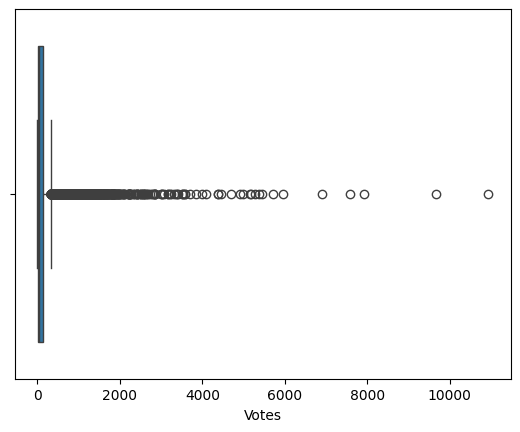

In [58]:
sns.boxplot(x = df["Votes"])

In [59]:
df[df["Votes"] == df["Votes"].max()]

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
728,51705,Toit,1,Bangalore,"298, Namma Metro Pillar 62, 100 Feet Road, Ind...",Indiranagar,"Indiranagar, Bangalore",77.640709,12.979166,"Italian, American, Pizza",...,Indian Rupees(Rs.),No,No,No,No,4,4.8,Dark Green,Excellent,10934


<Axes: ylabel='Average Cost for two'>

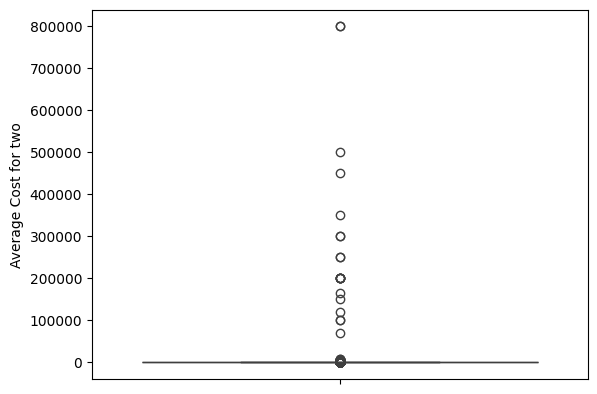

In [60]:
sns.boxplot(y = df["Average Cost for two"])

In [61]:
price_count = df["Price range"].value_counts().sort_index()
price_count

,count
Price range,
1,4444
2,3113
3,1408
4,586


Text(0.5, 1.0, 'Price Range Distribution')

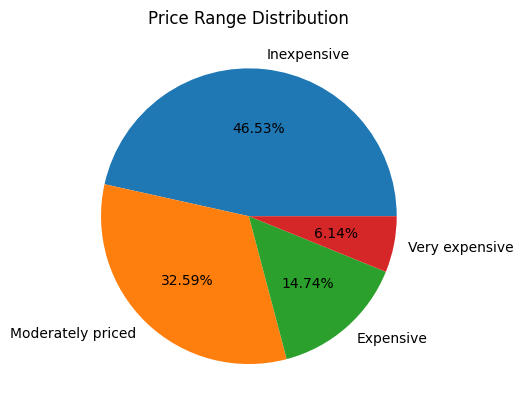

In [62]:
plt.pie(
    price_count.values,
    labels = ["Inexpensive","Moderately priced","Expensive","Very expensive"],
    autopct = "%.2f%%")
plt.title("Price Range Distribution")

In [63]:
top_cities = df["City"].value_counts().head(10)

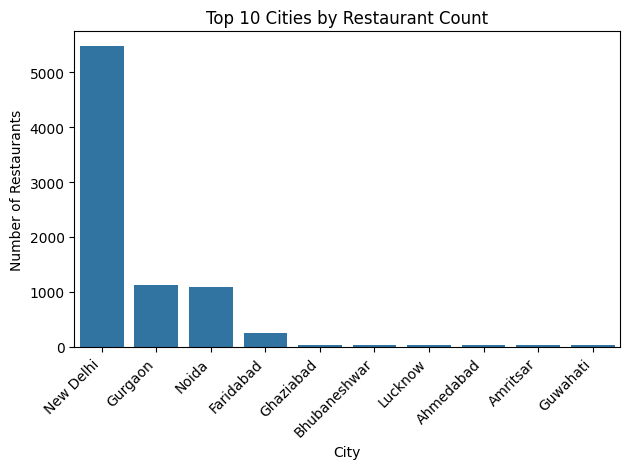

In [64]:
sns.barplot(x = top_cities.index , y = top_cities)
plt.title("Top 10 Cities by Restaurant Count")
plt.ylabel("Number of Restaurants")
plt.xlabel("City")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

---
## Phase 5 — Bivariate Analysis

**Business Scenario:** Explore relationships between two variables.  
**What we'll use:** Scatter plots, Box plots by category, Grouped statistics, Correlation.

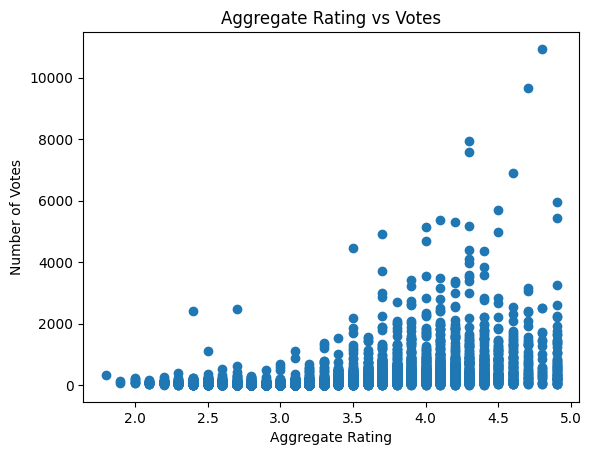

In [67]:
# Rating vs Votes

# Remove restaurants with a rating of 0
rated = df[df["Aggregate rating"] > 0]

# Create a scatter plot
plt.scatter(
    rated["Aggregate rating"],
    rated["Votes"]
)

plt.title("Aggregate Rating vs Votes")
plt.xlabel("Aggregate Rating")
plt.ylabel("Number of Votes")

plt.show()

In [68]:
#Correlation between Rating and Votes
correlation = rated["Aggregate rating"].corr(rated["Votes"])
correlation

np.float64(0.40901786341810925)

<Axes: title={'center': 'Aggregate rating'}, xlabel='Price range'>

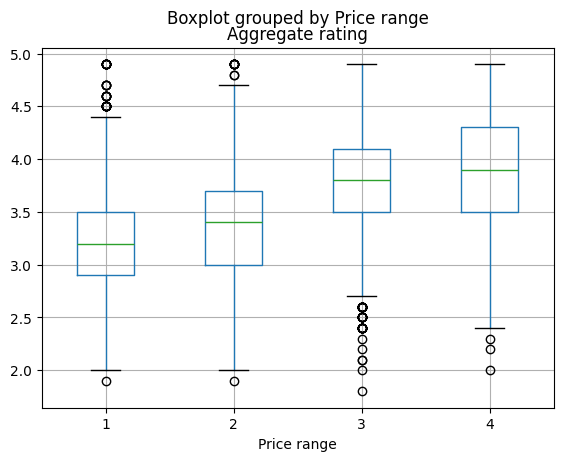

In [69]:
rated.boxplot(column = "Aggregate rating", by = "Price range")

In [70]:
# Average Rating of different Price range
rated.groupby("Price range")["Aggregate rating"].mean()

,Aggregate rating
Price range,
1,3.238885
2,3.377167
3,3.777276
4,3.890957


In [71]:
# Table Booking  vs Online Delivery

table = pd.crosstab(df["Has Table booking"],df["Has Online delivery"])
table

Has Online delivery,No,Yes
Has Table booking,,
No,6377,2016
Yes,723,435


<Axes: xlabel='Has Table booking'>

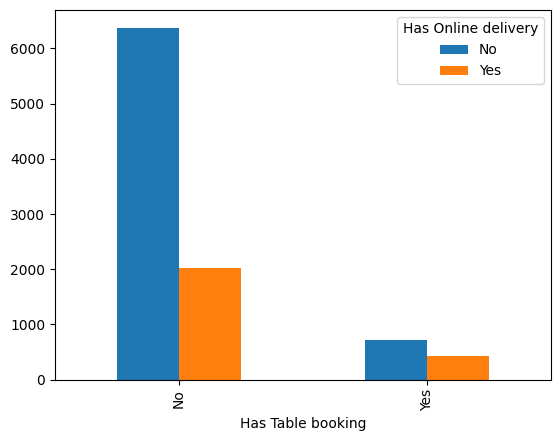

In [72]:
table.plot(kind = "bar")

In [74]:
# Correaltion between all the numeric columns

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9551 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [75]:
columns = [
    "Aggregate rating","Votes",
    "Average Cost for two","Price range"
]

correlation = df[columns].corr()
correlation


,Aggregate rating,Votes,Average Cost for two,Price range
Aggregate rating,1.000000,0.313691,0.051792,0.437944
Votes,0.313691,1.000000,0.067783,0.309444
Average Cost for two,0.051792,0.067783,1.000000,0.075083
Price range,0.437944,0.309444,0.075083,1.000000


<Axes: >

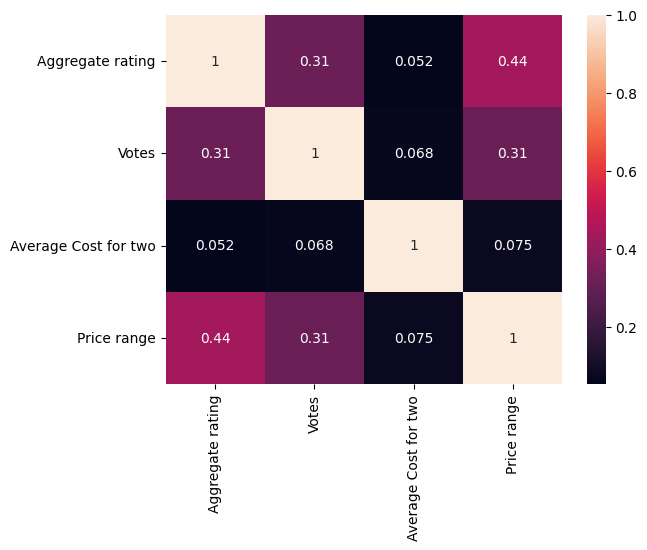

In [77]:
sns.heatmap(correlation,annot=True)

---
## Phase 6 — Multivariate Analysis

**Business Scenario:** Understand interactions between multiple variables simultaneously.  
**What we'll use:** Pair plots, multi-group comparisons, pivot tables.

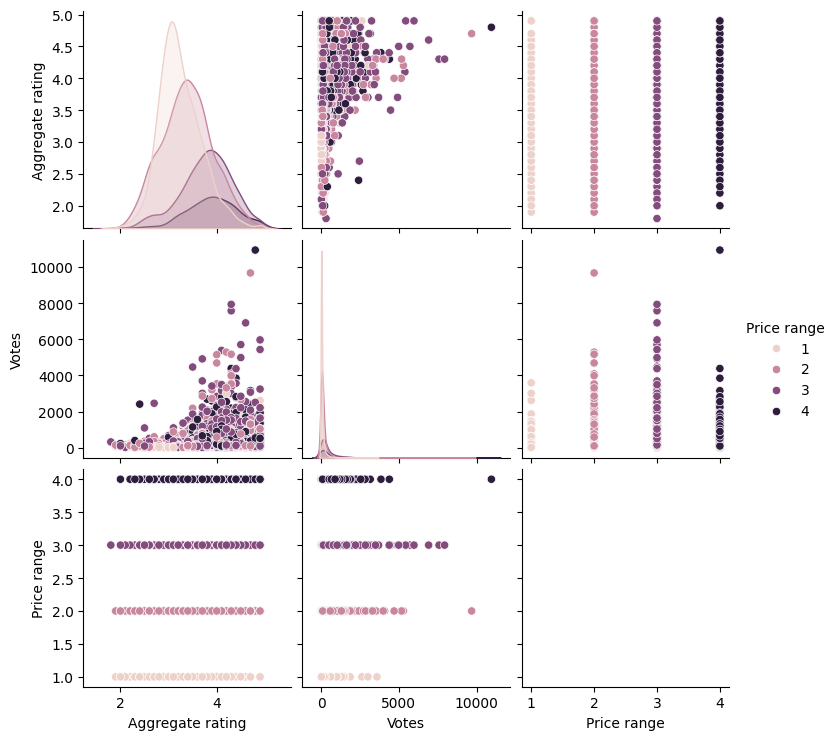

In [85]:
sns.pairplot(
    rated,
    vars=["Aggregate rating", "Votes", "Price range"],
    hue="Price range"
)

In [86]:
#Top 8 cities

top_cities = df["City"].value_counts().head(8)
top_cities

,count
City,
New Delhi,5473
Gurgaon,1118
Noida,1080
Faridabad,251
Ghaziabad,25
Bhubaneshwar,21
Lucknow,21
Ahmedabad,21


In [89]:
average_rating = df[df["City"].isin(top_cities.index)].groupby(["City","Has Online delivery"])["Aggregate rating"].mean()
average_rating

City          Has Online delivery
Ahmedabad     No                     4.110000
              Yes                    4.209091
Bhubaneshwar  No                     3.980952
Faridabad     No                     1.671296
              Yes                    3.074286
Ghaziabad     No                     2.613333
              Yes                    3.210000
Gurgaon       No                     2.256421
              Yes                    3.295529
Lucknow       No                     4.195238
New Delhi     No                     2.140186
              Yes                    3.237945
Noida         No                     1.580587
              Yes                    2.932418
Name: Aggregate rating, dtype: float64

In [90]:
pivot = df[df["City"].isin(top_cities.index)].pivot_table(
    index = "City",
    columns = "Has Online delivery",
    values = "Aggregate rating",
    aggfunc = "mean"
)

pivot

Has Online delivery,No,Yes
City,,
Ahmedabad,4.110000,4.209091
Bhubaneshwar,3.980952,NaN
Faridabad,1.671296,3.074286
Ghaziabad,2.613333,3.210000
Gurgaon,2.256421,3.295529
Lucknow,4.195238,NaN
New Delhi,2.140186,3.237945
Noida,1.580587,2.932418


<Axes: xlabel='City'>

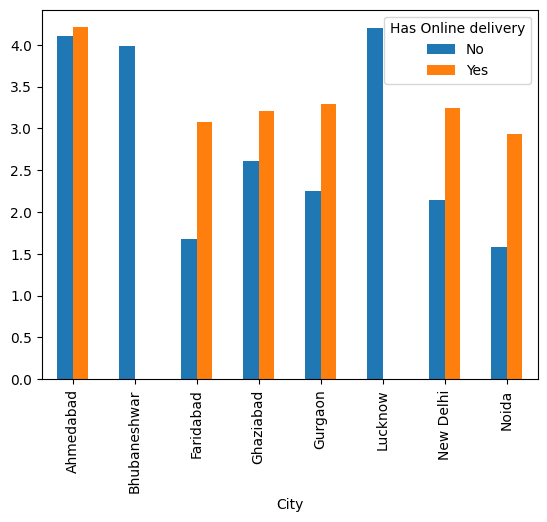

In [91]:
pivot.plot(kind = "bar")

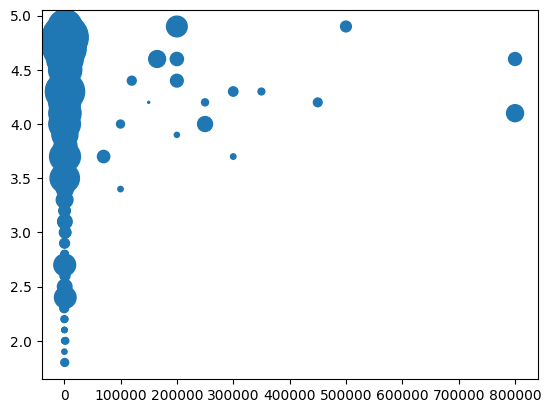

In [96]:
plt.scatter(
    rated["Average Cost for two"],
    rated["Aggregate rating"],
    rated["Votes"]/10
)



---
## Phase 7 — Outlier & Missing Value Analysis

**Business Scenario:** Outliers can distort analysis. We need to detect and decide what to do with them.  
**Methods:** IQR Method, Z-Score Method.

In [ ]:
# Detect outliers in Votes using the IQR method

# Find Q1 and Q3
Q1 = df["Votes"].quantile(0.25)
Q3 = df["Votes"].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Calculate the lower and upper limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Find outliers
outliers = df[
    (df["Votes"] < lower_limit) |
    (df["Votes"] > upper_limit)
]

# Display the results
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)
print("Number of Outliers:", len(outliers))

Q1: 5.0
Q3: 131.0
IQR: 126.0
Lower Limit: -184.0
Upper Limit: 320.0
Number of Outliers: 1126


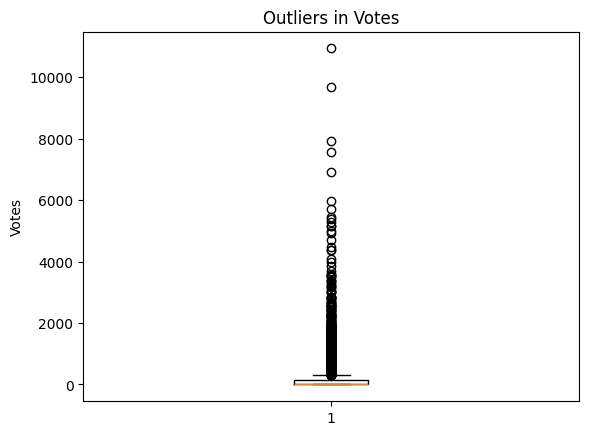

In [97]:
# Box Plot for Votes

plt.boxplot(df["Votes"])

plt.title("Outliers in Votes")
plt.ylabel("Votes")

plt.show()

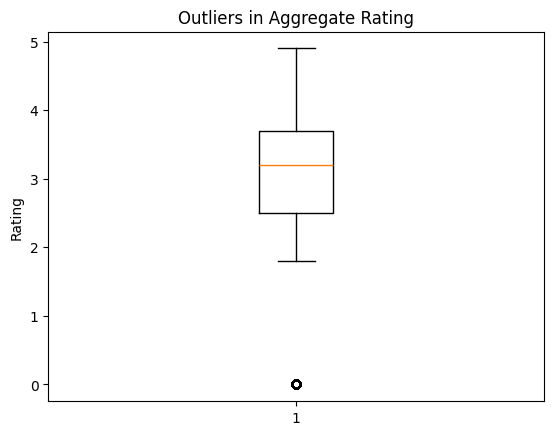

In [ ]:
# Box Plot for Aggregate Rating

plt.boxplot(df["Aggregate rating"])

plt.title("Outliers in Aggregate Rating")
plt.ylabel("Rating")

plt.show()

---
## Phase 8 — Feature Relationships & Pattern Discovery

**Business Scenario:** Discover trends, meaningful relationships, and hidden patterns in the data.

In [108]:
cusines_rating = (df[df["Aggregate rating"] > 0].groupby("Cuisines")["Aggregate rating"].agg(["mean","count"]).query("count >= 20").sort_values("mean",ascending = False).head(15))
cusines_rating

,mean,count
Cuisines,,
Italian,3.950000,50
American,3.920690,29
Mexican,3.850000,34
"Italian, Pizza",3.795652,23
Continental,3.745000,20
Desserts,3.597500,40
"Desserts, Ice Cream",3.570833,24
"Chinese, Thai",3.516667,48
"North Indian, Continental",3.515385,26


/tmp/ipykernel_1176/1425730195.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = cusines_rating["mean"], y = cusines_rating.index, palette = "viridis")


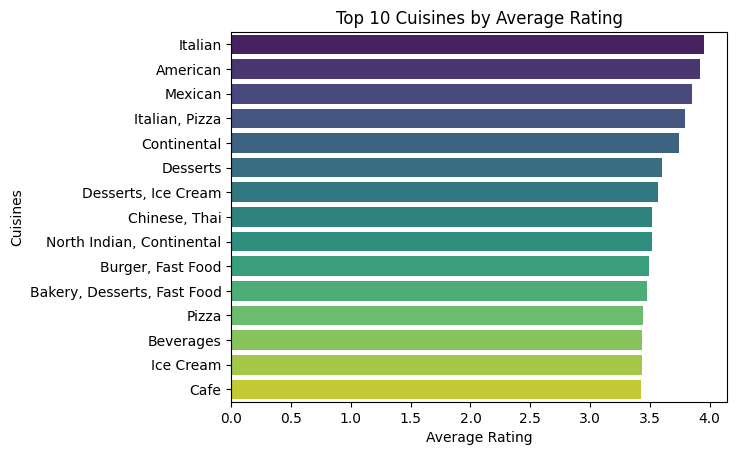

In [109]:
sns.barplot(x = cusines_rating["mean"], y = cusines_rating.index, palette = "viridis")
plt.title("Top 15 Cuisines by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Cuisines")
plt.show()

In [117]:
city_price_rating = (df[df["Aggregate rating"]>0].groupby(["Price range","Has Online delivery"])["Aggregate rating"].mean().unstack())
city_price_rating

Has Online delivery,No,Yes
Price range,,
1,3.231870,3.261574
2,3.414325,3.333414
3,3.833195,3.645477
4,3.886973,3.930189


<Axes: xlabel='Price range'>

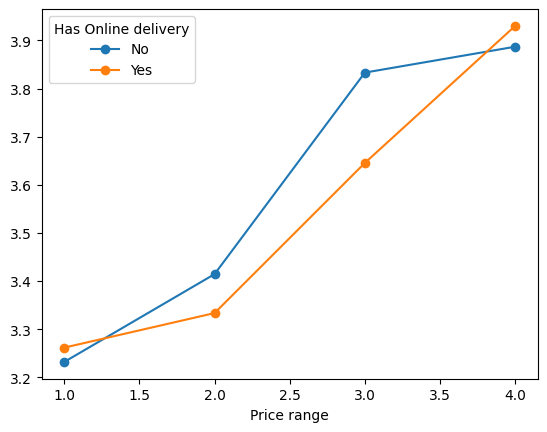

In [118]:
city_price_rating.plot(kind = "line",marker = "o")

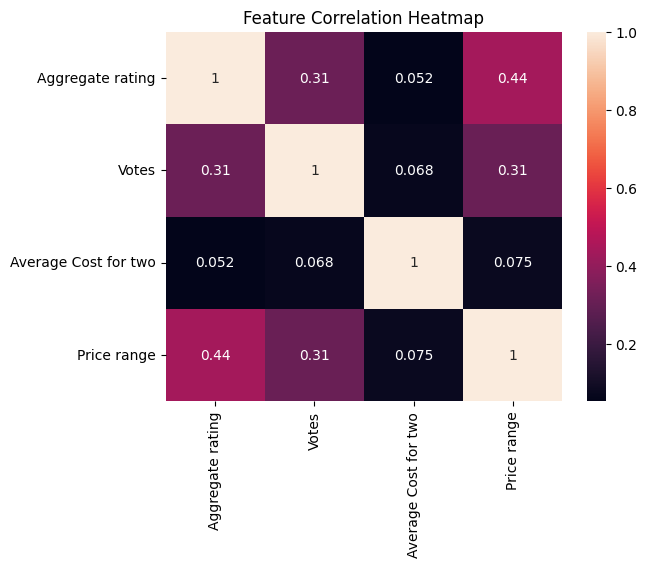

In [120]:
# Correlation Heatmap

# Select numerical columns
columns = [
    "Aggregate rating",
    "Votes",
    "Average Cost for two",
    "Price range"
]

# Calculate correlation
correlation = df[columns].corr()

# Create heatmap
sns.heatmap(
    correlation,
    annot=True
)

plt.title("Feature Correlation Heatmap")

plt.show()

---
## Phase 9 — Drawing Insights & Business Conclusions

**Business Scenario:** EDA is valuable only when it leads to actionable, data-driven recommendations.

Let's convert all our observations into real business insights.

In [ ]:
# KPI Summary

# Total number of restaurants
total_restaurants = len(df)

# Average rating
rated = df[df["Aggregate rating"] > 0]

average_rating = rated["Aggregate rating"].mean()

# Percentage of restaurants with online delivery
online_delivery = (
    df["Has Online delivery"] == "Yes"
).mean() * 100

# Percentage of restaurants with table booking
table_booking = (
    df["Has Table booking"] == "Yes"
).mean() * 100

# Find the city with the most restaurants
city_counts = df["City"].value_counts()

top_city = city_counts.index[0]
top_city_count = city_counts.iloc[0]

# Display the results
print("KPI Summary")
print("-" * 30)

print("Total Restaurants:", total_restaurants)
print("Average Rating:", round(average_rating, 2))
print("Online Delivery:", round(online_delivery, 1), "%")
print("Table Booking:", round(table_booking, 1), "%")
print("Top City:", top_city)
print("Restaurants in Top City:", top_city_count)

KPI Summary
------------------------------
Total Restaurants: 9551
Average Rating: 3.44
Online Delivery: 25.7 %
Table Booking: 12.1 %
Top City: New Delhi
Restaurants in Top City: 5473


## 1. Rating Category Distribution

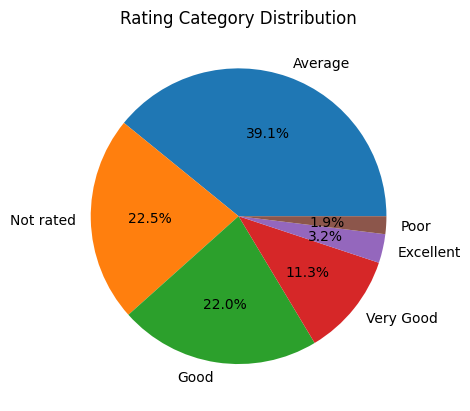

In [ ]:
# Rating Category Distribution

rating_counts = df["Rating text"].value_counts()

rating_counts.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Rating Category Distribution")
plt.ylabel("")

plt.show()

## 📋 Final Recommendations — Zomato EDA

### 1. Fix the Ratings Gap
**22.49%** of restaurants are "Not Rated." Zomato should send push notifications or offer incentives to encourage customers to leave ratings — this would improve both visibility and trust.

### 2. Promote Online Delivery
Only **25.66%** of restaurants offer online delivery, but their average rating (**3.25**) is noticeably better than restaurants without delivery (**2.47**). Onboarding non-delivery restaurants represents a high-impact opportunity for Zomato.

### 3. Table Booking Feature Is Underused
Only **12.12%** of restaurants offer table booking, and those that do have a better average rating (**3.44** vs **2.56** without booking). Zomato should promote this feature more widely, especially in the fine-dining segment.

### 4. Premium Restaurants Perform Better
Price range 4 (most expensive) has an average rating of **3.89**, compared to just **3.24** for price range 1 (cheapest). However, the correlation between cost and rating is weak (**0.08**) — meaning **being expensive alone doesn't guarantee a good rating**; quality and service matter more.

### 5. Votes Are a Trust Signal
The correlation between votes and rating is **0.41** — the more engagement a restaurant gets, the more stable/higher its rating tends to be. New restaurants should focus on collecting early reviews.

### 6. Winning Cuisines
**Italian (3.95)**, **American (3.92)**, and **Mexican (3.85)** are the top-rated cuisines (among those with at least 20 restaurants). Meanwhile, North Indian is the most common cuisine (936 restaurants) but its average rating isn't as high — a sign of **market saturation**, meaning differentiation is key.

### 7. Market Concentration Risk
Just 3 cities — **New Delhi, Gurgaon, and Noida** — account for over **77%** of all restaurants. Expansion strategy should focus on tier-2 cities where competition is lower.

### 8. Data Quality Note
The currency data shows this is a **multi-country dataset** (beyond India — includes US, UK, UAE, Brazil, etc.). If the analysis should be India-specific, filtering by `Currency = "Indian Rupees(Rs.)"` would ensure cost/rating comparisons are apples-to-apples.

In [ ]:
# Create a copy of the dataset
df_clean = df.copy()

In [ ]:
# Save the clean dataset

df_clean.to_csv(
    "zomato_clean.csv",
    index=False
)

print("Clean dataset saved successfully!")
print("Dataset is ready for Power BI or Machine Learning.")

Clean dataset saved successfully!
Dataset is ready for Power BI or Machine Learning.
